## Implementacion de Algortimos de Regresion para predecir el rendimeinto del cultivo del maiz.

-  Autor: Germán Homero Morán Figueroa
- Descripción: La Notebbok se realiza la implemntación y pruebas de los regresores lasso , ridge y elasticnet como alternativa para predecir el rendimiento del cultivo de maiz, con el objetivo se seleccionar el mejor regresor que permita realizar selección de atributos y eliminar colinealidades entre variables.

> Notas
* Para las variables binarias no se requiere hacer codificacion one - hot
* Probar con el regresor ElasticNet y verificar si efectivamente elimina variables colineales en cada grupo.
* Porbar con el regresor Lasso Y Ridge y Verificar su desempeño con el conjunto de datos
* Implementar SHAP como tecnica para analizar la importancia de las fetures en el problema de predicción
* Investigar y seleccionar un regresor que elimine la colinealidad entre variables.


In [1]:
# Librerias y Dependencias
# =======================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso , Ridge , LinearRegression , ElasticNet
from math import sqrt
from sklearn.metrics import r2_score
from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from numpy import arange
from numpy import absolute
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import RepeatedKFold
from sklearn.preprocessing import MinMaxScaler
import shap


C:\Users\germanm\AppData\Roaming\Python\Python39\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\germanm\AppData\Roaming\Python\Python39\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
'''
    Esta clase permite realizar la codificación en caliente especificameente variables categoricas
'''

class OneHotCoding():
    def __init__(self, df, bin_features):
        self.bin_features = bin_features
        self.df = df
    
    # Metodo para realizar la codificacion dummy a las variables categoricas

    def dummyCodification(self):
        cat_features = self.df.select_dtypes(include = ["object", "category"]).columns
        bin_dataset = self.df[self.bin_features].replace({'SI': 1, 'NO': 0})
        categorical_features = [x for x in cat_features if x not in self.bin_features]
        df_cat = pd.get_dummies(self.df[categorical_features],dtype=int)
        self.df.drop(cat_features, axis = 1, inplace = True)
        df_final = pd.concat([self.df,df_cat,bin_dataset ], axis = 1)
        print("Ejeción Terminada")
        return df_final


#categorical_transformer = Pipeline(
#    steps=[("OneHotCoding",  OneHotCoding(df,bin_features).dummyCodification())]
#)

In [4]:
# 1. Lectura del dataframe Original
# ============================================================
df = pd.read_excel("../../../Data/Gold/DatasetFinal.xlsx")
bin_features =['SEM_TRATADAS','DRENAJE','ALMACENAMIENTO_FINCA','CAP_ENDURE_RASTA','MOTEADOS_RASTA','MOTEADOS_MAS70cm._RASTA',
               'OBSERVA_EROSION_RASTA','OBSERVA_MOHO_RASTA','OBSERVA_RAICES_VIVAS_RASTA','OBSERVA_HOJARASCA_MO_RASTA',
                'SUELO_NEGRO_BLANDO_RASTA','CUCHILLO_PRIMER_HTE_RASTA','CERCA_RIOS_QUEBRADAS_RASTA',
               ]


#2. Codificación de variables categoricas - Dummy
# ============================================================
dataset = OneHotCoding(df,bin_features).dummyCodification()
print("Dimension dataset Original: ", dataset.shape)


Ejeción Terminada
Dimension dataset Original:  (799, 176)


C:\Users\germanm\AppData\Local\Temp\ipykernel_9012\1899041560.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  bin_dataset = self.df[self.bin_features].replace({'SI': 1, 'NO': 0})


In [13]:
dataset.head(5)

,ID_LOTE,DIAS_EN_EMERGER,DIAS_EN_EMERGER_A_FLORECER,DIAS_EN_FLORECER_A_COSECHAR,POBLACION_20DIAS_AJT,ALTURA_LOT,ContEnfQui_Emer_Flor,ContEnfQui_Flor_Cose,ContMalMec_Siem_Emer,ContMalMec_Emer_Flor,...,CAP_ENDURE_RASTA,MOTEADOS_RASTA,MOTEADOS_MAS70cm._RASTA,OBSERVA_EROSION_RASTA,OBSERVA_MOHO_RASTA,OBSERVA_RAICES_VIVAS_RASTA,OBSERVA_HOJARASCA_MO_RASTA,SUELO_NEGRO_BLANDO_RASTA,CUCHILLO_PRIMER_HTE_RASTA,CERCA_RIOS_QUEBRADAS_RASTA
0,40,5,63,68,60000,13,0,0,0,0,...,0,1,0,0,0,0,0,0,1,0
1,43,5,64,63,60000,15,0,0,0,0,...,1,1,0,0,0,0,1,0,1,0
2,44,5,59,66,60000,12,0,0,0,0,...,1,1,0,0,0,1,1,0,1,0
3,45,5,64,59,60000,12,0,0,0,0,...,1,1,0,0,0,0,1,0,0,0
4,46,5,63,60,60000,16,0,0,0,0,...,1,1,0,0,0,0,1,0,0,0


In [16]:
# Division de los datos | Variable Dependiente (Y) , Variable Independiente (Y)
# ===============================================================================
Y = dataset.RDT_AJUSTADO
X = dataset.drop(["RDT_AJUSTADO","ID_LOTE"], axis=1)

In [17]:
# Se deviden los datos en conjunto de entranmiento y test para pruebas
# =====================================================================================

scaler= MinMaxScaler()
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.20, random_state=40)
X_train_scaled = scaler.fit_transform(X_train)  
X_test_scaled = scaler.transform(X_test)  
print(X_train.shape); print(X_test.shape)


(639, 174)
(160, 174)


##  Modelado

## 1. Implementación  Elasticnet Model

* ElasticNet se caracteriza porque incliye penalizacion L1 Y L2
* Elastic Net es un modelo de regresión lineal que combina las penalizaciones de Ridge Regression (L2) y Lasso Regression (L1). Es útil cuando hay muchas variables correlacionadas, ya que puede seleccionar características como Lasso, pero también mantener la estabilidad de los coeficientes como Ridge.

In [ ]:

# Hiperparametros (Validación Cruzada)
# ===========================================
ratios = arange(0, 1, 0.01)
alphas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.0, 1.0, 10.0, 100.0]

# Metodo de evaluación del modelo
# ===========================================
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

# Modelo
# =========================================
model = ElasticNetCV(l1_ratio=ratios, alphas=alphas, cv=cv)

# Ajuste
# =========================================
model.fit(X, Y)
r2_training = model.score(X, Y)


print('alpha: %f' % model.alpha_)
print('l1_ratio_: %f' % model.l1_ratio_)
print(f"Coeficiente de determinación (R²) en todo el dataset: {r2_training:.4f}")

c:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:633: UserWarning: Coordinate descent with alpha=0 may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent_gram(
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:633: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 329042225.5528319, tolerance: 138951.7394895896
  model = cd_fast.enet_coordinate_descent_gram(
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:633: UserWarning: Coordinate descent with alpha=0 may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent_gram(
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:633: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 302131115.61093324, 

alpha: 0.100000
l1_ratio_: 0.970000
Coeficiente de determinación (R²) en todo el dataset: 0.7420


c:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.906e+07, tolerance: 1.533e+05
  model = cd_fast.enet_coordinate_descent(


**Nota**: Despues del proceso de validación cruzada se obtuvo que los mejor parametros de la red Elasticnet fueron: 
* alpha: 0.1
* li_ratio:0.97

## 1.1 Importancia de Caracteristicas

In [5]:

# Implementación modelo Elasticnet (Meajor Combinación)
# ============================================================
modelEN = ElasticNet(alpha=1.0, l1_ratio=0.97)
modelEN.fit(X_train_scaled, y_train)
y_pred = modelEN.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print("Ajuste conjunto Test: ", r2)

# Guardamos coeficeinte Elasticnet
# ======================================================
elnet_coeff = pd.DataFrame()
elnet_coeff["Columns"] = X_train.columns
elnet_coeff['Coefficient Estimate'] = pd.Series(np.abs(modelEN.coef_))
elnet_coeff = elnet_coeff.sort_values(by="Coefficient Estimate", ascending=False)

#  Top 10
top_10_features = elnet_coeff.head(10)

# Graficar en un diagrama de barras
plt.figure(figsize=(10, 5))
plt.barh(top_10_features["Columns"], top_10_features["Coefficient Estimate"], color="steelblue")
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features - ElasticNet")
plt.gca().invert_yaxis() 
plt.show()


NameError: name 'X_train_scaled' is not defined

##  Cómo interpretar los coeficientes después de normalizar X
1. El impacto relativo de cada variable en y

    - Un coeficiente más alto significa que esa variable tiene más influencia en la predicción.

    - Un coeficiente cerca de 0 significa que esa variable no tiene un impacto significativo.

2. La magnitud del coeficiente refleja la contribución de una variable escalada

    - Como X está normalizado, los coeficientes ya no dependen de la escala original de las variables.

    - Ejemplo: Si coef_ = 50 para una variable normalizada, significa que un cambio de una unidad estándar en esa variable aumenta y en 50 unidades.

## 1.2 SHAP para verificar la importancia de las caracteristicas

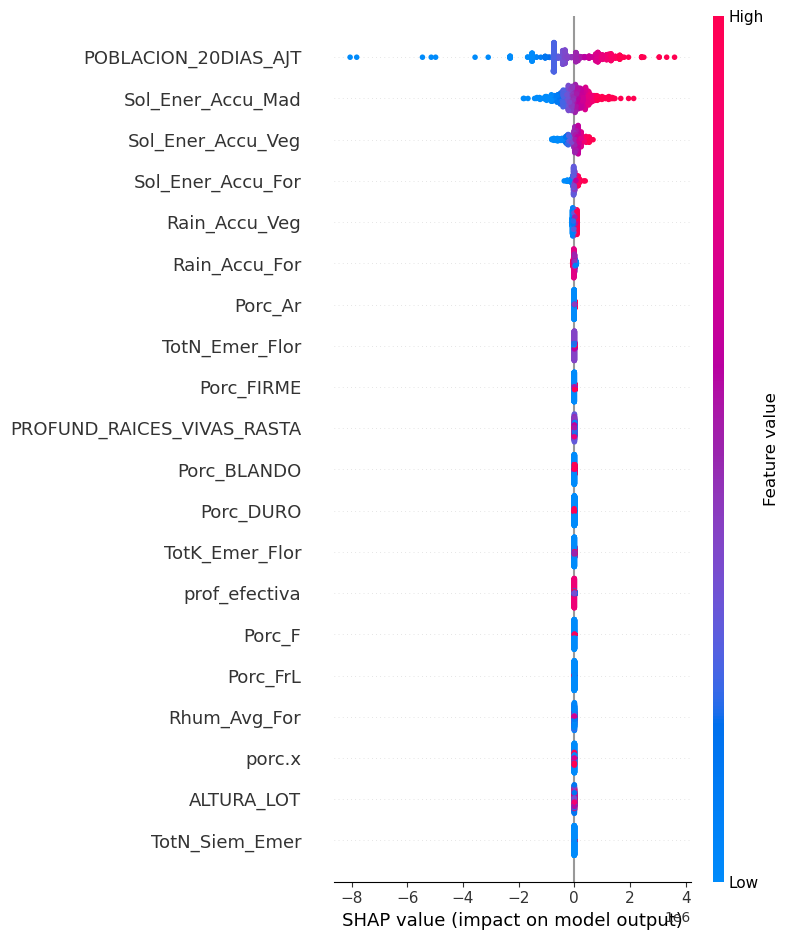

In [31]:
# Crear el objeto SHAP explainer para ElasticNet
explainer = shap.Explainer(modelEN, X_train)

# Calcular los valores SHAP con Training
shap_values = explainer(X_train)

# Gráfico de resumen con las características más importantes
shap.summary_plot(shap_values, X_train)


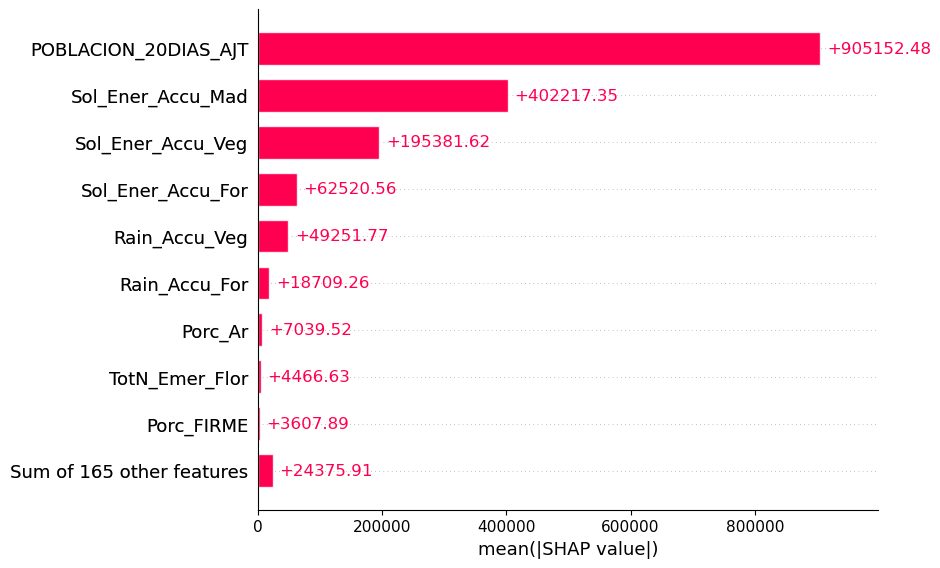

In [33]:
# Importancia  Global de las Variables en la Predicción
# ===============================================================
shap.plots.bar(shap_values,max_display=10)

### Importancia de Usar SHAP
- Mejor interpretación: No solo muestra la importancia de la variable, sino también si su efecto es positivo o negativo.
- Funciona muestra por muestra: Puedes ver cómo cada variable afecta cada predicción individual.
- Más confiable que solo mirar los coeficientes: Especialmente cuando hay correlación entre variables.

## 2. Implementación de Lasso Model
- Agrega una penalización L1 (||β||_1), que fuerza algunos coeficientes a ser exactamente 0.
-  Selecciona automáticamente las variables más importantes.
- Selecciona automáticamente las variables más importantes, el modelo es mas simple y Explicable

In [34]:


# Hiperparámetros para validación cruzada
alphas = [1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 0.0, 1.0, 10.0, 100.0]

# Método de evaluación del modelo (Validación Cruzada)
cv = RepeatedKFold(n_splits=10, n_repeats=3, random_state=1)

# Modelo Lasso con búsqueda de alpha óptimo
model_lasso = LassoCV(alphas=alphas, cv=cv)

# Ajustar el modelo
model_lasso.fit(X, Y)
r2_training_lasso = model_lasso.score(X, Y)
# Resultados
print('Lasso - Mejor alpha:', model_lasso.alpha_)
print(f"Lasso - R² en todo el dataset: {r2_training_lasso:.4f}")


c:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:633: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 342547.0275655389, tolerance: 138951.7394895896
  model = cd_fast.enet_coordinate_descent_gram(
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:633: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 107524557.24360824, tolerance: 138951.7394895896
  model = cd_fast.enet_coordinate_descent_gram(
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:633: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 155014672.81963998, tolerance: 138951.7394895896
  model = cd_fast.enet_coordinate_descent_gram(
c:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:633: 

Lasso - Mejor alpha: 1.0
Lasso - R² en todo el dataset: 0.7461


c:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.082e+07, tolerance: 1.533e+05
  model = cd_fast.enet_coordinate_descent(


Ajuste conjunto Test:  0.5755058810921454
La cantidad de coeficientes elimninados fue de:  (52, 2)


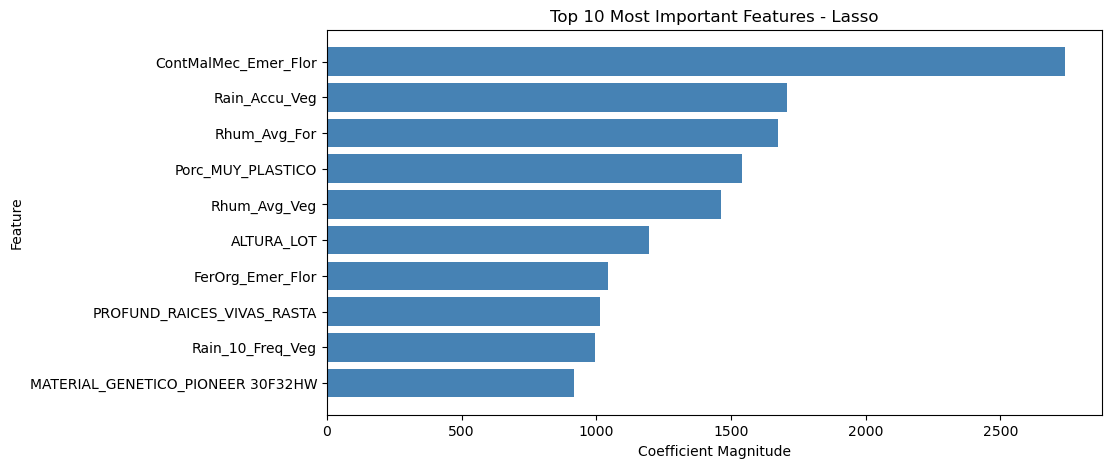

In [ ]:
# Implementación modelo lasso (Meajor Combinación)
# ============================================================
modelLasso = Lasso(alpha=1.0)
modelLasso.fit(X_train_scaled, y_train)
y_pred = modelLasso.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print("Ajuste conjunto Test: ", r2)

# Guardamos coeficeinte Lasso
# ================================================================================
lasso_coeff = pd.DataFrame()
lasso_coeff["Columns"] = X_train.columns
lasso_coeff['Coefficient Estimate'] = pd.Series(np.abs(modelLasso.coef_))
lasso_coeff = lasso_coeff.sort_values(by="Coefficient Estimate", ascending=False)


top_10_features = lasso_coeff.head(10)
atributos_eli = lasso_coeff[lasso_coeff['Coefficient Estimate'] == 0] 
print("La cantidad de coeficientes elimninados fue de: ",  atributos_eli.shape)



plt.figure(figsize=(10, 5))
plt.barh(top_10_features["Columns"], top_10_features["Coefficient Estimate"], color="steelblue")
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features - Lasso")
plt.gca().invert_yaxis() 
plt.show()


## 3. Implementación de Ridge Model
- Reduce el tamaño de los coeficientes pero no los vuelve exactamente cero
- Funciona bien cuando existen muchas variables correlacionadas  

In [ ]:
# Modelo Ridge con búsqueda de alpha óptimo
model_ridge = RidgeCV(alphas=alphas, cv=cv)

# Ajustar el modelo
model_ridge.fit(X, Y)
r2_training_ridge = model_ridge.score(X, Y)

# Resultados
print('Ridge - Mejor alpha:', model_ridge.alpha_)
print(f"Ridge - R² en todo el dataset: {r2_training_ridge:.4f}")


Ridge - Mejor alpha: 1.0
Ridge - R² en todo el dataset: 0.7503


Ajuste conjunto Test:  0.6036241924863168
La cantidad de coeficientes elimninados fue de:  (52, 2)


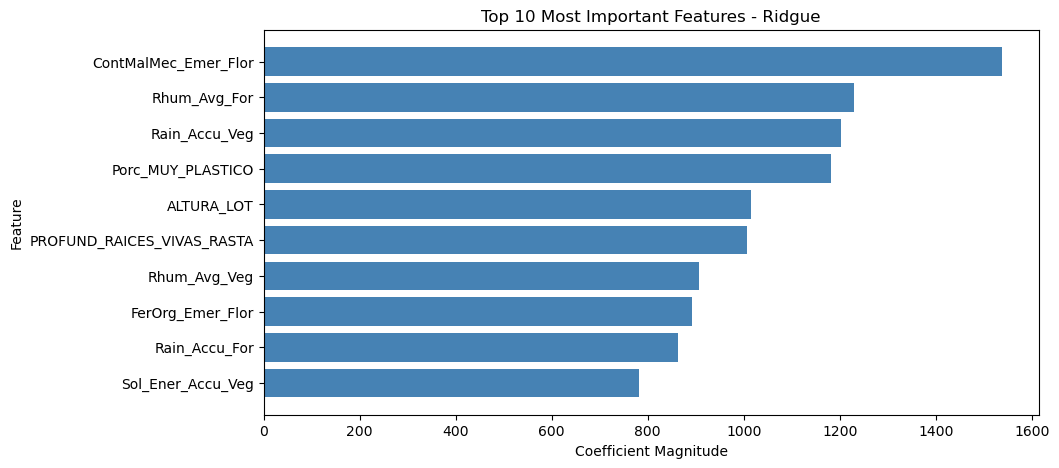

In [ ]:
# Implementación modelo Ridge (Meajor Combinación)
# ============================================================
modelRidge = Ridge(alpha=1.0)
modelRidge.fit(X_train_scaled, y_train)
y_pred = modelRidge.predict(X_test_scaled)
r2 = r2_score(y_test, y_pred)
print("Ajuste conjunto Test: ", r2)

# Guardamos coeficeinte Ridge
# ================================================================================
ridge_coeff = pd.DataFrame()
ridge_coeff["Columns"] = X_train.columns
ridge_coeff['Coefficient Estimate'] = pd.Series(np.abs(modelRidge.coef_))
ridge_coeff = ridge_coeff.sort_values(by="Coefficient Estimate", ascending=False)


top_10_features = ridge_coeff.head(10)
print("La cantidad de coeficientes elimninados fue de: ",  atributos_eli.shape)



plt.figure(figsize=(10, 5))
plt.barh(top_10_features["Columns"], top_10_features["Coefficient Estimate"], color="steelblue")
plt.xlabel("Coefficient Magnitude")
plt.ylabel("Feature")
plt.title("Top 10 Most Important Features - Ridgue")
plt.gca().invert_yaxis() 
plt.show()


### Conclusión

- Para la implementación del algortimo CLR y modelos de regresión asociados a cada grupo se implemneta el modelo Elasticnet debido a que funciona bien con la colinealidad, ademas permite realizar seleccion de atributos mediante la eliminacion de variables no relevantes
- Otra razon para elejir elasticnet es que permite controlar el sobreajuste de manera adecuada

### Referencias

- https://cienciadedatos.net/documentos/py14-ridge-lasso-elastic-net-python

- https://shap.readthedocs.io/en/latest/

- https://sitiobigdata.com/2018/08/27/machine-learning-metricas-regresion-mse/#

- https://machinelearningmastery.com/lasso-regression-with-python/

- https://machinelearningmastery.com/ridge-regression-with-python/

- https://machinelearningmastery.com/elastic-net-regression-in-python/